# Phase 3: Question Selection and Validation
**Tiller Restaurant Analytics Project**

**Objective:** Evaluate all four candidate business questions and select the strongest one for detailed analysis.  
**Date:** September 10, 2026

---

## 1. Context and Objective

### Background
Phase 2 identified demand forecasting as one of the strongest opportunities in the Tiller data because:
- Substantial historical transaction data across 21 stores
- Clear patterns in demand over time
- 5 years of data (Oct 2015 – Nov 2020)
- 1.28M orders to analyze

### The Challenge
Multiple candidate questions could address demand forecasting, but they differ in business value, analytical approach, product implications, and feasibility.

### Phase 3 Objective
Evaluate all four candidate questions at equal depth to make a **defensible selection based on evidence**, not assumptions.

In [1]:
import subprocess
from io import StringIO
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

# Tiller Design System
COLORS = {
    'primary': '#3063E9',
    'black': '#111827',
    'gray': '#4B5563',
    'light': '#9CA3AF',
    'grid': '#E5E7EB',
    'bg': '#FFFFFF',
}

plt.rcParams.update({
    'figure.facecolor': COLORS['bg'],
    'axes.facecolor': COLORS['bg'],
    'axes.edgecolor': COLORS['grid'],
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'text.color': COLORS['black'],
    'font.size': 10,
    'grid.color': COLORS['grid'],
    'grid.linewidth': 0.6,
    'grid.alpha': 0.7,
})

# Project-root charts folder (works whether cwd is root or notebooks/)
_root = Path.cwd()
if _root.name == 'notebooks':
    _root = _root.parent
CHARTS_DIR = _root / 'charts' / '03_opportunity_definition'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

def run_query(query):
    result = subprocess.run(
        ['bq', 'query', '--use_legacy_sql=false', '--format=csv', query],
        capture_output=True, text=True,
    )
    if result.returncode != 0:
        raise RuntimeError(f'Query failed: {result.stderr}')
    return pd.read_csv(StringIO(result.stdout))

def save_and_show(fig, filename):
    plt.tight_layout()
    path = CHARTS_DIR / filename
    fig.savefig(path, dpi=200, bbox_inches='tight', facecolor=COLORS['bg'])
    plt.show()
    plt.close(fig)
    print(f'  ✓ Saved: {path.relative_to(_root)}')

## 2. The Four Candidate Questions

| ID | Question | Focus | Risk |
|----|----------|-------|------|
| **Q1** | Can Tiller identify patterns in store-level demand over time? | Descriptive patterns | May stay interesting without action |
| **Q2** | Can Tiller forecast weekly store-level demand 1–2 weeks ahead using historical patterns? | Historical forecast | Accuracy may be limited |
| **Q3** | Can Tiller accurately forecast demand using historical **and calendar** patterns? | Forecast + calendar | Calendar may add complexity without value |
| **Q4** | Can Tiller use AI/ML to forecast store-level demand? | ML approaches | Technology-first framing |

---

## 3. Evaluation Framework

Each question is scored on the same 10 criteria: business relevance, evidence, analytical signal, depth, actionability, product potential, advanced analytics opportunity, feasibility, risks, overall assessment.

## 4. Data Foundation

Confirm the dataset can support a forecasting investigation before scoring questions.

In [2]:
query = '''
WITH store_stats AS (
  SELECT
    id_store,
    DATE_DIFF(MAX(DATE(date_opened)), MIN(DATE(date_opened)), DAY) AS tenure_days,
    COUNT(*) AS total_orders
  FROM `le-wagon-da-502302.tiller.order_data`
  GROUP BY id_store
)
SELECT 'Total stores' AS metric, CAST(COUNT(*) AS STRING) AS value FROM store_stats
UNION ALL
SELECT 'Stores with >1 year', CAST(SUM(CASE WHEN tenure_days >= 365 THEN 1 ELSE 0 END) AS STRING) FROM store_stats
UNION ALL
SELECT 'Stores with >2 years', CAST(SUM(CASE WHEN tenure_days >= 730 THEN 1 ELSE 0 END) AS STRING) FROM store_stats
UNION ALL
SELECT 'Total orders', CAST(SUM(total_orders) AS STRING) FROM store_stats
'''
df_foundation = run_query(query)
print('Data Foundation:')
print(df_foundation.to_string(index=False))

Data Foundation:
              metric   value
        Total stores      21
 Stores with >1 year      21
Stores with >2 years      19
        Total orders 1281148


**Result:** Strong foundation — 21 stores, 19 with >2 years history, ~1.28M orders.

## 5. Testing Analytical Signal

### 5.1 Store variation (supports Q1–Q4)
Do stores differ enough in demand that store-level analysis is meaningful?

In [3]:
query_variation = '''
WITH daily_agg AS (
  SELECT id_store, DATE(date_opened) AS order_date, COUNT(*) AS orders
  FROM `le-wagon-da-502302.tiller.order_data`
  GROUP BY id_store, DATE(date_opened)
),
store_profiles AS (
  SELECT id_store, AVG(orders) AS mean,
         ROUND(STDDEV(orders) / AVG(orders), 2) AS cv
  FROM daily_agg
  GROUP BY id_store
)
SELECT
  ROUND(MIN(mean), 1) AS min_mean,
  ROUND(MAX(mean), 1) AS max_mean,
  ROUND(MAX(mean) / MIN(mean), 1) AS max_min_ratio,
  ROUND(AVG(cv), 2) AS avg_cv
FROM store_profiles
'''
df_variation = run_query(query_variation)
print('Store Variation:')
print(df_variation.to_string(index=False))
print(f"\nInterpretation: {df_variation['max_min_ratio'].values[0]:.1f}x difference between smallest and largest stores")

Store Variation:
 min_mean  max_mean  max_min_ratio  avg_cv
      8.5    1188.8          139.8    0.49

Interpretation: 139.8x difference between smallest and largest stores


**Finding:** Strong variation (~139.8×) — meaningful differences between stores.

### 5.2 Temporal autocorrelation (supports Q1–Q4)
Does recent demand relate to the next day?

In [4]:
query_temporal = '''
WITH daily_agg AS (
  SELECT id_store, DATE(date_opened) AS order_date, COUNT(*) AS orders
  FROM `le-wagon-da-502302.tiller.order_data`
  GROUP BY id_store, DATE(date_opened)
),
with_lag AS (
  SELECT id_store, order_date, orders,
         LAG(orders, 1) OVER (PARTITION BY id_store ORDER BY order_date) AS lag_1d
  FROM daily_agg
),
correlations AS (
  SELECT id_store, ROUND(CORR(orders, lag_1d), 3) AS corr_1d
  FROM with_lag
  WHERE lag_1d IS NOT NULL
  GROUP BY id_store
)
SELECT ROUND(AVG(corr_1d), 3) AS avg_corr FROM correlations
'''
df_temporal = run_query(query_temporal)
print(f"Average temporal autocorrelation: {df_temporal['avg_corr'].values[0]:.3f}")
print('Interpretation: Moderate-strong temporal patterns exist')

Average temporal autocorrelation: 0.396
Interpretation: Moderate-strong temporal patterns exist


**Finding:** Temporal patterns exist (avg corr ≈ 0.396).

### 5.3 Day-of-week patterns (supports Q1–Q3)

In [5]:
query_dow = '''
WITH daily_agg AS (
  SELECT id_store, DATE(date_opened) AS order_date, COUNT(*) AS orders
  FROM `le-wagon-da-502302.tiller.order_data`
  GROUP BY id_store, DATE(date_opened)
),
dow_agg AS (
  SELECT id_store, EXTRACT(DAYOFWEEK FROM order_date) AS dow, AVG(orders) AS avg_orders
  FROM daily_agg
  GROUP BY id_store, EXTRACT(DAYOFWEEK FROM order_date)
),
store_range AS (
  SELECT id_store, MAX(avg_orders) / MIN(avg_orders) AS dow_ratio
  FROM dow_agg
  GROUP BY id_store
)
SELECT ROUND(AVG(dow_ratio), 2) AS avg_ratio, ROUND(MAX(dow_ratio), 2) AS max_ratio
FROM store_range
'''
df_dow = run_query(query_dow)
print(f"Average DOW ratio: {df_dow['avg_ratio'].values[0]:.2f}x")
print(f"Maximum DOW ratio: {df_dow['max_ratio'].values[0]:.2f}x")
print('Interpretation: Strong day-of-week patterns exist')

Average DOW ratio: 7.68x
Maximum DOW ratio: 33.43x
Interpretation: Strong day-of-week patterns exist


**Finding:** Very strong DOW patterns (avg ratio ≈ 7.68×).

### 5.4 Weekly forecasting viability (supports Q2–Q4)

In [6]:
query_weekly = '''
WITH weekly_agg AS (
  SELECT id_store, DATE_TRUNC(DATE(date_opened), WEEK) AS week, COUNT(*) AS orders
  FROM `le-wagon-da-502302.tiller.order_data`
  GROUP BY 1, 2
),
with_lag AS (
  SELECT id_store, week, orders,
         LAG(orders, 1) OVER (PARTITION BY id_store ORDER BY week) AS lag_1w
  FROM weekly_agg
),
store_performance AS (
  SELECT id_store,
         ROUND(CORR(orders, lag_1w), 3) AS lag_corr,
         ROUND(AVG(orders), 1) AS avg_orders,
         ROUND(STDDEV(orders) / AVG(orders), 2) AS cv,
         COUNT(*) AS weeks
  FROM with_lag
  WHERE lag_1w IS NOT NULL
  GROUP BY 1
)
SELECT * FROM store_performance
ORDER BY avg_orders DESC
'''
df_weekly = run_query(query_weekly)
print('Weekly forecasting viability by store:')
print(df_weekly.to_string(index=False))
print(f"\nMedian lag correlation: {df_weekly['lag_corr'].median():.3f}")
print(f"Stores with corr > 0.3: {(df_weekly['lag_corr'] > 0.3).sum()} / {len(df_weekly)}")

Weekly forecasting viability by store:
 id_store  lag_corr  avg_orders   cv  weeks
     4151     0.919      5841.3 0.54    149
     5281     0.851       903.1 0.33    141
     8291     0.797       648.1 0.30     83
     5617     0.626       175.8 0.63     97
     6008     0.095       159.5 0.32    116
     2035     0.705       149.8 0.32    204
     4803     0.701       140.2 0.36    128
     6827     0.655       130.7 0.33    113
     5210     0.380        98.4 0.26    133
     1513     0.801        97.7 0.29    232
     4364     0.618        88.2 0.39    149
     7786     0.651        77.0 0.45     82
      351     0.520        71.5 0.25    205
     5498     0.555        70.3 0.50    132
     6830     0.674        66.6 0.35    115
      360     0.519        58.3 0.29    209
     7872     0.753        58.3 0.38     92
     5860     0.336        51.8 0.31     87
     7304     0.445        51.6 0.30     97
      730     0.741        45.7 0.62    219
     4196     0.585        43.0 0.44 

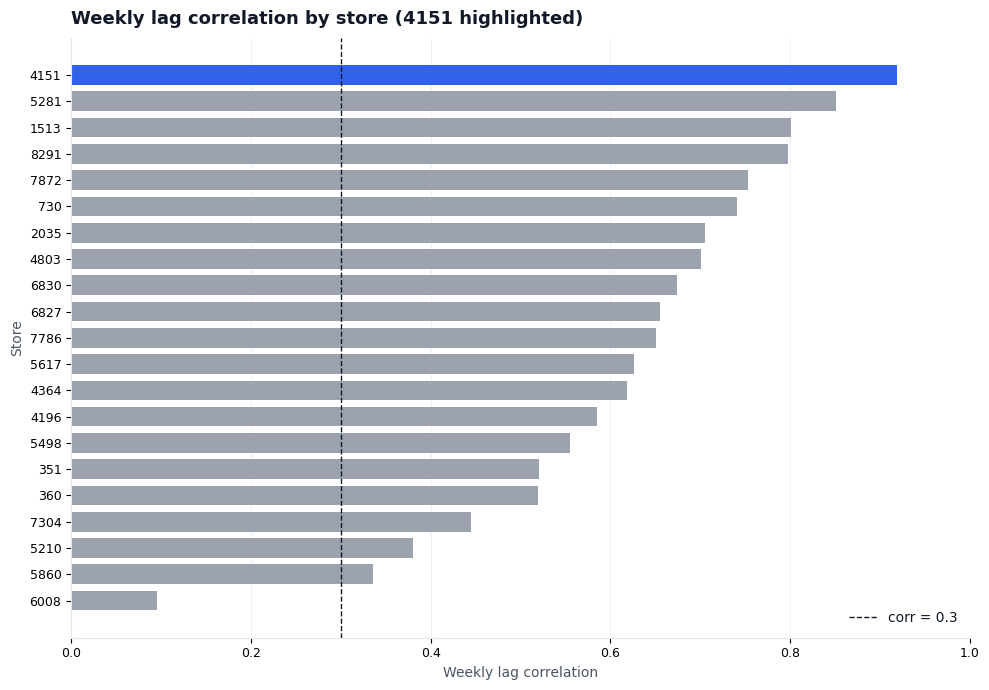

  ✓ Saved: charts/03_opportunity_definition/3_weekly_lag_correlation_by_store.png


In [7]:
# Chart: Weekly lag correlation by store (Tiller style)
fig, ax = plt.subplots(figsize=(10, 7))
df_plot = df_weekly.sort_values('lag_corr', ascending=True)
# Highlight Store 4151
bar_colors = [COLORS['primary'] if sid == 4151 else COLORS['light'] for sid in df_plot['id_store']]
ax.barh(df_plot['id_store'].astype(str), df_plot['lag_corr'], color=bar_colors, edgecolor='none', height=0.75)
ax.axvline(0.3, color=COLORS['black'], linestyle='--', linewidth=1, label='corr = 0.3')
ax.set_xlabel('Weekly lag correlation', color=COLORS['gray'])
ax.set_ylabel('Store', color=COLORS['gray'])
ax.set_title('Weekly lag correlation by store (4151 highlighted)', color=COLORS['black'], loc='left', pad=10, fontweight='semibold')
ax.xaxis.grid(True, color=COLORS['grid'], alpha=0.7)
ax.set_axisbelow(True)
ax.set_xlim(0, 1)
ax.legend(frameon=False, loc='lower right')
ax.spines['left'].set_color(COLORS['grid'])
ax.spines['bottom'].set_color(COLORS['grid'])
save_and_show(fig, '3_weekly_lag_correlation_by_store.png')

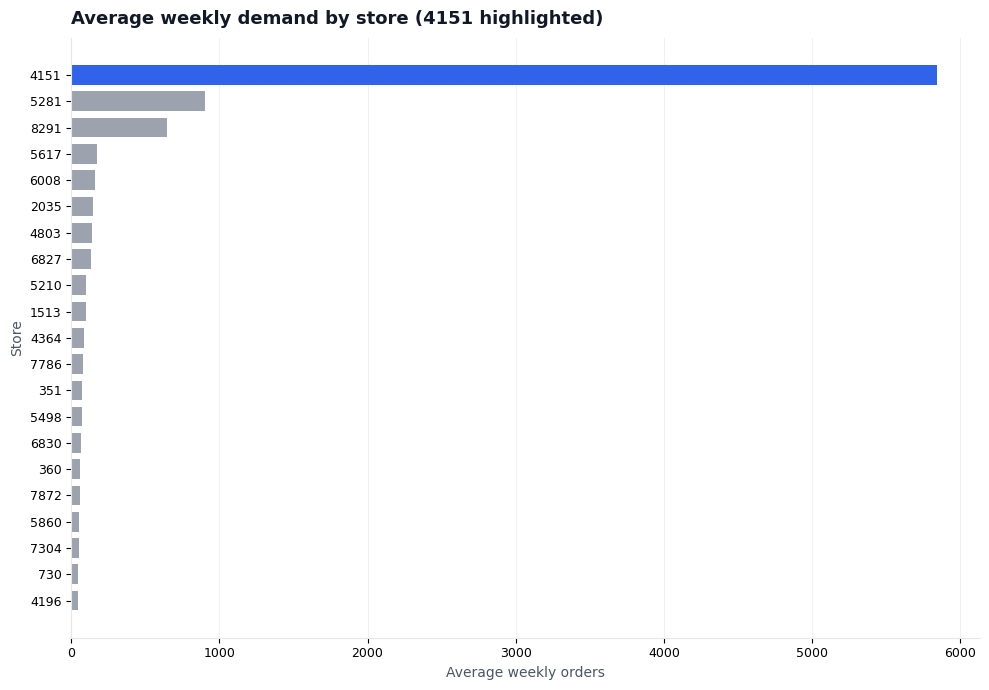

  ✓ Saved: charts/03_opportunity_definition/3_avg_weekly_orders_by_store.png


In [8]:
# Chart: Avg weekly orders by store (volume context)
fig, ax = plt.subplots(figsize=(10, 7))
df_vol = df_weekly.sort_values('avg_orders', ascending=True)
bar_colors = [COLORS['primary'] if sid == 4151 else COLORS['light'] for sid in df_vol['id_store']]
ax.barh(df_vol['id_store'].astype(str), df_vol['avg_orders'], color=bar_colors, edgecolor='none', height=0.75)
ax.set_xlabel('Average weekly orders', color=COLORS['gray'])
ax.set_ylabel('Store', color=COLORS['gray'])
ax.set_title('Average weekly demand by store (4151 highlighted)', color=COLORS['black'], loc='left', pad=10, fontweight='semibold')
ax.xaxis.grid(True, color=COLORS['grid'], alpha=0.7)
ax.set_axisbelow(True)
ax.set_xlim(0, None)
ax.spines['left'].set_color(COLORS['grid'])
ax.spines['bottom'].set_color(COLORS['grid'])
save_and_show(fig, '3_avg_weekly_orders_by_store.png')

**Finding:** Strong weekly signal — median lag correlation ≈ 0.651; 20/21 stores above 0.3.

## 6. Question Evaluation Results

### Q1 — Pattern identification
- **Strengths:** Strong patterns (variation, DOW); feasible; clear relevance for understanding demand  
- **Weaknesses:** Actionability gap; mostly descriptive depth  
- **Verdict:** MODERATE–HIGH — keep as supporting analysis  

### Q2 — Historical forecasting
- **Strengths:** Strongest weekly signal; clearest path to decisions (staffing, inventory); high product potential; feasible  
- **Weaknesses:** Forecast error still material; Store 4151 volume concentration  
- **Verdict:** **HIGH — SELECTED**  

### Q3 — Historical + calendar forecasting
- **Strengths:** Same business value as Q2; calendar features easy to test  
- **Weaknesses:** Weak standalone calendar signal in exploration; risk of complexity without gain  
- **Verdict:** MODERATE–HIGH — test calendar **inside** Q2, not as a separate question  

### Q4 — AI/ML forecasting
- **Strengths:** Room for advanced methods; rich features  
- **Weaknesses:** Technology-first framing; must beat simple baselines  
- **Verdict:** MODERATE–HIGH — test ML **inside** Q2, not as the question itself  

---

## 7. Head-to-head comparison

| Criterion | Q1 Patterns | Q2 Historical | Q3 Hist+Cal | Q4 AI/ML |
|-----------|-------------|---------------|-------------|----------|
| Business relevance | MOD–HIGH | **HIGH** | HIGH | HIGH |
| Evidence | STRONG | **STRONG** | MOD–STRONG | STRONG |
| Analytical signal | STRONG | **STRONG** | MODERATE | MOD–HIGH |
| Actionability | MODERATE | **HIGH** | HIGH | HIGH |
| Product potential | MODERATE | **HIGH** | MOD–HIGH | MOD–HIGH |
| Feasibility | STRONG | **STRONG** | STRONG | MOD–STRONG |
| **OVERALL** | MOD–HIGH | **HIGH** | MOD–HIGH | MOD–HIGH |

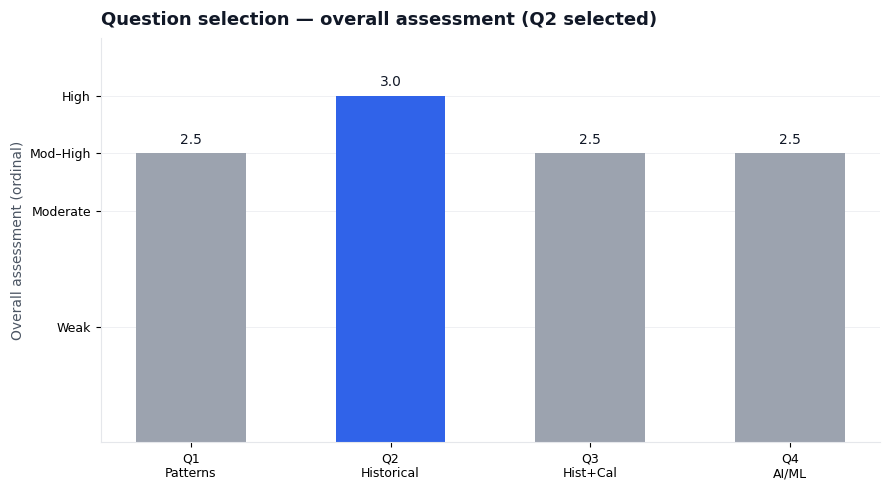

  ✓ Saved: charts/03_opportunity_definition/3_question_overall_comparison.png


In [9]:
# Chart: qualitative scores for overall (for visual readout)
# Scores mapped: HIGH=3, MOD-HIGH=2.5, MODERATE=2, MOD-STRONG=2.5, STRONG=3
criteria = ['Business\nrelevance', 'Evidence', 'Analytical\nsignal', 'Actionability',
            'Product\npotential', 'Feasibility']
# Q2 emphasis — only overall comparison bars for the four questions on a single metric set
questions = ['Q1\nPatterns', 'Q2\nHistorical', 'Q3\nHist+Cal', 'Q4\nAI/ML']
# Overall ordinal for chart: MOD-HIGH=2.5, HIGH=3
overall = [2.5, 3.0, 2.5, 2.5]
bar_colors = [COLORS['light'], COLORS['primary'], COLORS['light'], COLORS['light']]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(questions, overall, color=bar_colors, edgecolor='none', width=0.55)
ax.set_ylim(0, 3.5)
ax.set_ylabel('Overall assessment (ordinal)', color=COLORS['gray'])
ax.set_title('Question selection — overall assessment (Q2 selected)', color=COLORS['black'], loc='left', pad=10, fontweight='semibold')
ax.yaxis.grid(True, color=COLORS['grid'], alpha=0.7)
ax.set_axisbelow(True)
ax.set_yticks([1, 2, 2.5, 3])
ax.set_yticklabels(['Weak', 'Moderate', 'Mod–High', 'High'])
ax.spines['left'].set_color(COLORS['grid'])
ax.spines['bottom'].set_color(COLORS['grid'])
for i, v in enumerate(overall):
    ax.text(i, v + 0.08, f'{v:.1f}', ha='center', color=COLORS['black'], fontsize=10)
save_and_show(fig, '3_question_overall_comparison.png')

## 8. Final Decision

### Selected question
**Q2:** *Can Tiller forecast weekly store-level demand 1–2 weeks ahead using historical patterns?*

### Top three reasons
1. **Strongest analytical signal** — median weekly lag corr ≈ 0.651; 20/21 stores > 0.3  
2. **Clearest business value** — forecast → planning decisions (staffing, inventory)  
3. **Best depth vs feasibility** — room for features/ML tests without changing the question  

### Why not the others
- **Q1:** Actionability gap (patterns still need a decision path)  
- **Q3:** Calendar not proven enough to redefine the question  
- **Q4:** ML is a method hypothesis, not the business question  

---

## 9. Key evidence summary

| Area | Evidence |
|------|----------|
| Data foundation | 21 stores, ~1.28M orders, 5 years; 19 stores with >2 years |
| Weekly baseline signal | Median lag corr ≈ 0.651; 20/21 stores > 0.3 |
| Store concentration | Store 4151 ~68% volume — report store-level and aggregate carefully |
| Calendar (exploratory) | Strong DOW ratios; weak week-of-year standalone signal → test inside Q2 |

---

## 10. Next steps

Phase 4 / focused forecasting analysis within **Q2**:
1. Recent demand predicts next week (lag baselines)  
2. Multiple historical windows (smoothing / averages)  
3. Store characteristics and forecastability  
4. Calendar features as a **hypothesis** (not assumed)  
5. More complex methods only if they beat simple baselines  

Keep the investigation **evidence-driven**, not method-driven.

---

## Conclusion

Phase 3 evaluated four candidate questions at equal depth.  
**Q2 (historical weekly forecasting)** was selected on signal strength, decision value, and feasibility.  
Q3 and Q4 remain testable **hypotheses inside Q2**, not alternative primary questions.